# Isle Royale National Park Visitation Analysis

**Group**: Isle of Data Royalist

**Members**: Alice Morgan, An Nguyen, Lydia Tembreull

## Project Overview
This project analyzes 46 years of visitation data from Isle Royale National Park from the years 1979-2024. Isle Royale is a wilderness island located in Lake Superior that can only be accessed by boat or seaplane. Because of the harsh winters and remote location of the island, the park is only open for the months of mid-April to October.

## Objective
The goal of this analysis is to clean up the historic "messy" data, conduct and exploratory data analysis (EDA) on the seasonal differences in visitation, and breakdown types of stays (indoor vs. outdoor) over time.

#### Dataset 
The dataset `ParkData.csv` contains monthly counts for various metrics including:
- **Recreation Visitors**: Total headcount of visitors.
- **Stay Types**: Breakdown of stays including Concession Lodging, Tent Camping, and Backcountry Camping.
- **Operational Metrics**: Visitor hours and non-recreation stays.

#### Approach
1. **Data Cleaning**: Handle missing values and convert formatted strings (with commas) into integers.
2. **Feature Engineering**: Transform categorical month names and years into a proper time-series index.
3. **Exploratory Data Analysis**: Analyze the impact of the park's operating season vs. the full calendar year.
4. **Comparative Analysis**: Evaluate infrastructure usage (Lodging) against wilderness usage (Backcountry).

# Library Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Data Cleaning & Preprocessing

In [2]:
# Load initial data
df = pd.read_csv('ParkData.csv')

# Drop trailing empty column/rows
df = df.dropna(axis = 1, how = 'all')
df = df.dropna(subset = ['Year', 'Month'])

# print shape of data
df.shape # Should get 552 rows and 14 columns

(552, 14)

### Create Custom Cleaning Function
This is needed because Pandas reads "1,000" as a string instead of a number.

In [3]:
# Function to remove commas in numbers
def clean_number(value):
    if pd.isna(value):
        return 0
    if (type(value) == str):
        # Removes commas to allow conversion to integer
        clean_val = value.replace(',', '').strip()
        try:
            return clean_val
        except ValueError:
            return 0
    return value

# Define columns that should be treated as numeric
numeric_cols = [
    'Recreation Visitors',
    'Non-Recreation Visitors',
    'Recreation Visitor Hours',
    'Non-Recreation Hours',
    'Concession Lodging',
    'Tent Campers',
    'RV Campers',
    'Concession Camping',
    'Backcountry Campers',
    'Misc Campers',
    'Non-Recreation Overnight Stays',
    'Total Overnight Stays'
]

# Apply the cleaning logic and convert types
for col in numeric_cols:
    df[col] = df[col].apply(clean_number).astype(int)

### Time-Series Transformation
We want to convert string months to numbers for data object creation.

In [4]:
# Convert Year and Month to Date Column
# Create dictionary to map month names to numbers
month_map = {
    'January': 1,
    'February': 2,
    'March': 3,
    'April': 4,
    'May': 5,
    'June': 6,
    'July': 7,
    'August': 8,
    'September': 9,
    'October': 10,
    'November': 11,
    'December': 12
}

# Create date column
df['Month_Num'] = df['Month'].map(month_map)
df['Year'] = df['Year'].astype(int) # makes Year column into integer instead of float

# Create a unified 'Date' column to facilitate time-series plotting
df['Date'] = pd.to_datetime(pd.DataFrame({
    'year': df['Year'],
    'month': df['Month_Num'],
    'day': 1
}))

# Export cleaned data for reproducibility 
df.to_csv('Cleaned_ParkData.csv', index = False)

# Exploratory Data Analysis (EDA)
In this section, we anlayze the distribution of visitors and validate the data against known park constraints, such as Isle Royale's lack of RV access.

### Initial EDA (Full Dataset)
We begin by examining the entire 46-year dataset to understand the raw distributions and identify any data anomalies before filtering for seasonality.

In [5]:
# Summary statistics validation
# Checks data integrity after cleaning
print('Number of Missing Values per Column:')
print(df.isnull().sum())

# Generate descriptive statistics for numeric columns
# Drop temporal columns to focuse purely on visitation volume
print('\nSummary Statistics:')
display(df.drop(columns = ['Year', 'Month', 'Month_Num', 'Date']).describe())

Number of Missing Values per Column:
Year                              0
Month                             0
Recreation Visitors               0
Non-Recreation Visitors           0
Recreation Visitor Hours          0
Non-Recreation Hours              0
Concession Lodging                0
Tent Campers                      0
RV Campers                        0
Concession Camping                0
Backcountry Campers               0
Misc Campers                      0
Non-Recreation Overnight Stays    0
Total Overnight Stays             0
Month_Num                         0
Date                              0
dtype: int64

Summary Statistics:


,Recreation Visitors,Non-Recreation Visitors,Recreation Visitor Hours,Non-Recreation Hours,Concession Lodging,Tent Campers,RV Campers,Concession Camping,Backcountry Campers,Misc Campers,Non-Recreation Overnight Stays,Total Overnight Stays
count,552.000000,552.000000,552.000000,552.000000,552.000000,552.000000,552.0,552.000000,552.000000,552.000000,552.000000,552.000000
mean,1692.844203,20.820652,110385.882246,1487.293478,639.693841,564.331522,0.0,64.298913,2841.583333,391.347826,61.581522,4562.836957
std,2635.870738,110.543561,171092.449471,2282.068775,1127.900159,1076.173733,0.0,161.672641,4384.047489,873.213833,94.948513,7025.329337
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000
25%,41.000000,0.000000,41.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000
50%,193.500000,2.000000,1082.500000,144.000000,0.000000,0.000000,0.0,0.000000,14.000000,0.000000,4.500000,100.000000
75%,2495.750000,17.000000,175379.250000,2208.000000,952.250000,860.250000,0.0,39.000000,4375.250000,348.750000,91.000000,7348.000000
max,10861.000000,1814.000000,683855.000000,14748.000000,4895.000000,12695.000000,0.0,1291.000000,17635.000000,7195.000000,614.000000,27741.000000


**Data Observations: Full Dataset**
- **Completeness**: The first table confirms that there no missing values across all columns.
- **Skewness**: Visitation data is highly right-skewed. The `Recreation Visitors` mean (1692.84) is significantly greater than the median (193.50). This confirms that visitation data is primarily influenced by seasonal closure and extreme highs during summer travel season.
- **Validation**: The entire `RV Campers` columns is 0, which acts as a successful data validaton, since Isle Royale is only accessible by boat or seaplane.
- **Stay Preference**: `Backcountry Campers` greatly outnumber `Concession Lodging`, which shows that infrastructure demand for the park is providing wilderness adventure and not traditional hospitality services.

#### Visualizing Distributions & Correlations

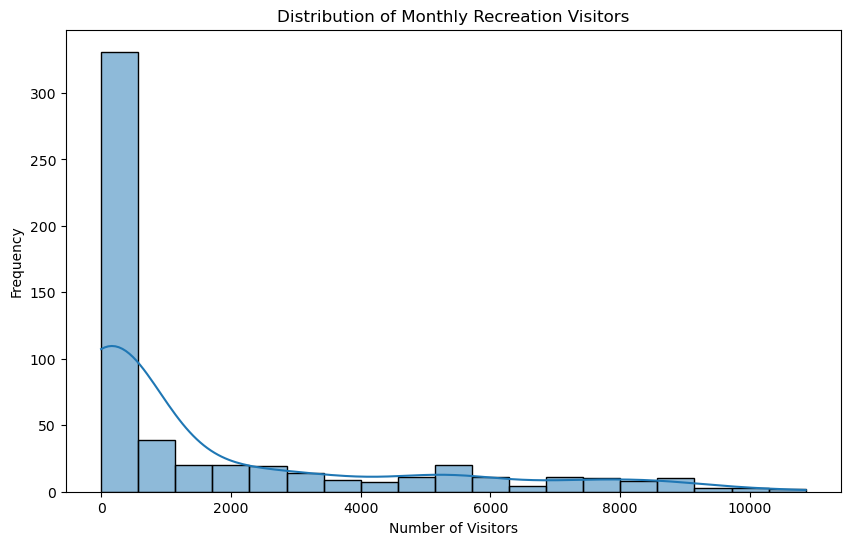

In [6]:
# Distribution of Recreation Visitors
plt.figure(figsize = (10, 6))

sns.histplot(df['Recreation Visitors'], kde = True)

plt.title('Distribution of Monthly Recreation Visitors')
plt.xlabel('Number of Visitors')
plt.ylabel('Frequency')
plt.show()

**Finding**: The heavy right-skew is caused by the park being closed for half the year and the long tail represents high-intensity summer months at full operational copacity.

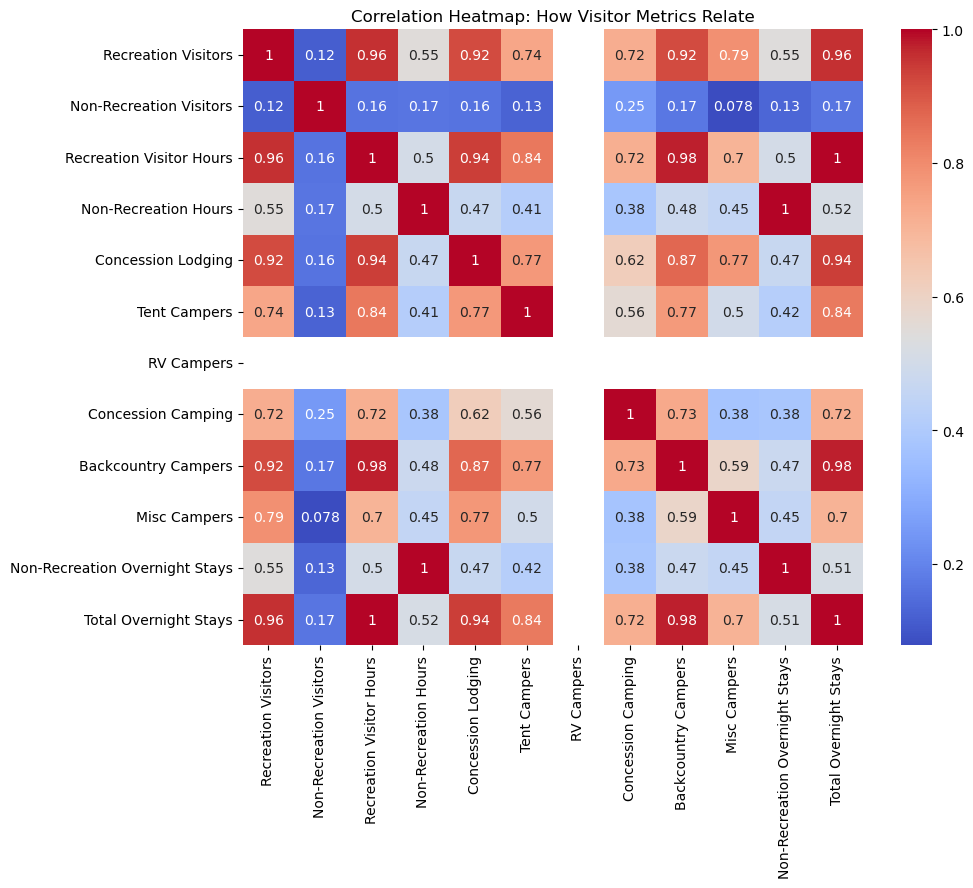

In [7]:
# Correlation heatmap to see relationships between different visitor types
plt.figure(figsize = (10, 8))

# Removing non-numeric/time columns to calculate correlation matrix
corr_matrix = df.drop(columns = ['Year', 'Month', 'Month_Num', 'Date']).corr()
sns.heatmap(corr_matrix, annot = True, cmap = 'coolwarm')

plt.title('Correlation Heatmap: How Visitor Metrics Relate')
plt.show()

**Heatmap Analysis**:
- **Primary Drivers:** The 3 main drivers of visitation that have a correlation > 0.95 are `Recreation Visitors`, `Recreation Visitor Hours`, and `Total Overnight Stays`. This means that as visitation increases, the duration of stays remain consistent, suggesting that visitors stay on Isle Royale for longer periods of time instead of just quickly stopping by.
- **Wilderness vs. Intrastructure:** Both `Backcountry Campers` and `Tent Campers` have high correlations with total recreation visitors, which indicate that the park's growth heavily depends on wilderness infrastructure like trails and campsites.
- **Independent Metrics:** `Non-Recreation Visitors`show low correlation, suggesting administrative/research activity remains steady regardless of tourist peaks.

#### Temporal Trends & Composition

<Figure size 1200x600 with 0 Axes>

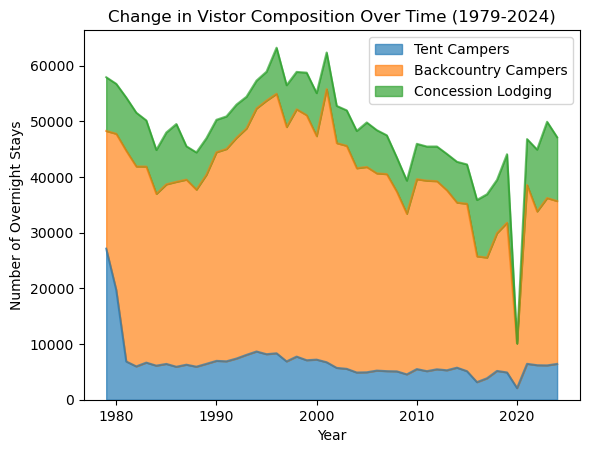

In [8]:
# Visualizing the change in how people stay at the park over 46 years
# Grouping by year and looking at proportion of different camper types
plt.figure(figsize = (12, 6))

composition_data = df.groupby('Year')[['Tent Campers', 'Backcountry Campers', 'Concession Lodging']].sum()
composition_data.plot(kind = 'area', stacked = True, alpha = 0.67)

plt.title('Change in Vistor Composition Over Time (1979-2024)')
plt.ylabel('Number of Overnight Stays')
plt.legend(loc = 'upper right')
plt.show()

**Observation**: `Backcountry Camping` has remained the dominant mode of overnight stay on Isle Royale from 1979 to 2024. While `Concession Lodging` is fixed by physical room capacity, the backcountry absorbs the surges in visitation.

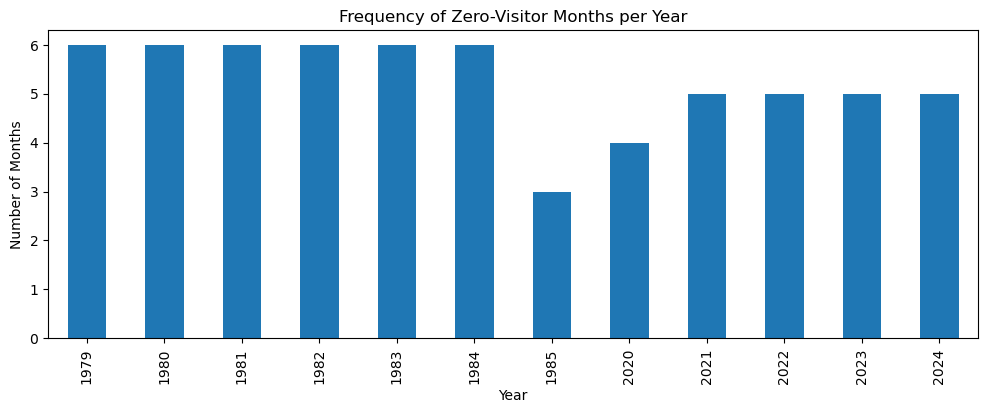

In [9]:
# Investigating the 'Zero-Visitor' months to understand operational boundaries
plt.figure(figsize = (12, 4))

zero_months = df[df['Recreation Visitors'] == 0].groupby('Year').size()
zero_months.plot(kind = 'bar')

plt.title('Frequency of Zero-Visitor Months per Year')
plt.ylabel('Number of Months')
plt.show()

**Operational Shift**: The frequency of zero-visitor months provides a unique look at the park's operational boundaries. While a 5.5-month closure was the standard for the first 25 years of the dataset, we observe a significant shift in the last few years (2020–2024), where zero-visitor months have dropped to 4 or 5. This suggests an expansion of the "active" season, likely due to shoulder-season maintenance or climate-related changes allowing for earlier/later access. Additionally, the anomaly in 1985 (only 3 months of zero visitors) marks a period of high off-season activity that warrants further historical investigation.

### Addressing Seasonality

**The Seasonality Problem**: We observed that the almost 6-month winter closure creates an artifically heavy right-skew and potentially inflates correlations. To get a more accurate view of park operations, we will now analyze a subset of "Open Season" months (April-October).

In [10]:
# Creating subset of operating months (April 16 - October 31)
df_open = df[(df['Month_Num'] >= 4) & (df['Month_Num'] <= 10)].copy()
df_open.to_csv('Open_Season_ParkData.csv', index = False)

### Refined EDA (Operating Months Only)
By removing the months the park is closed, we can see the "true" average of a working park month.

In [11]:
# Summary statistics for numeric columns for operating season
print('\nSummary Statistics for Operating Season:')
display(df_open.drop(columns = ['Year', 'Month', 'Month_Num', 'Date']).describe())


Summary Statistics for Operating Season:


,Recreation Visitors,Non-Recreation Visitors,Recreation Visitor Hours,Non-Recreation Hours,Concession Lodging,Tent Campers,RV Campers,Concession Camping,Backcountry Campers,Misc Campers,Non-Recreation Overnight Stays,Total Overnight Stays
count,322.000000,322.000000,322.000000,322.000000,322.000000,322.000000,322.0,322.000000,322.000000,322.000000,322.000000,322.000000
mean,2859.819876,34.245342,189161.891304,2375.257764,1096.618012,967.425466,0.0,110.226708,4871.285714,670.881988,98.335404,7814.773292
std,2939.488903,143.059642,187900.896988,2552.559037,1296.550095,1263.645025,0.0,199.469284,4803.442397,1058.643012,106.348891,7697.962995
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000
25%,253.500000,2.000000,9142.500000,273.000000,0.000000,49.500000,0.0,0.000000,233.500000,31.000000,10.000000,429.500000
50%,1806.500000,11.500000,122827.500000,1540.000000,514.000000,662.500000,0.0,21.000000,3417.500000,243.000000,64.500000,5042.000000
75%,5160.250000,25.750000,370733.750000,3668.000000,2066.250000,1441.000000,0.0,127.750000,8648.500000,897.500000,152.250000,15090.250000
max,10861.000000,1814.000000,683855.000000,14748.000000,4895.000000,12695.000000,0.0,1291.000000,17635.000000,7195.000000,614.000000,27741.000000


**Comparative Analysis**:
- **Sample Sie**: The subset reduces the count from 552 to 322 months.
- **Median Shift**: The `Recreation Visitors` median jumped from 193 to 1806, which provides a much more realistic figure for resource management planning.

#### Distribution of Recreation Visitors on Operating Season

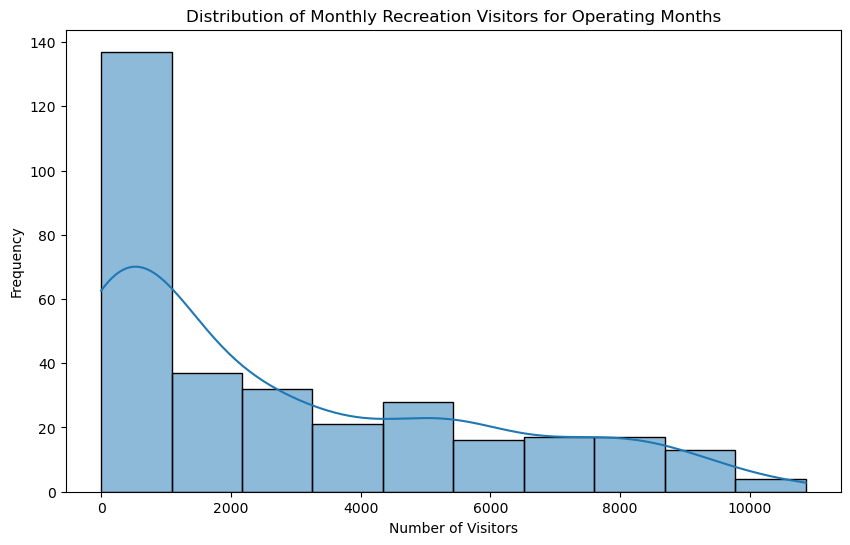

In [12]:
# Distribution of Recreation Visitors on operating months
plt.figure(figsize = (10, 6))

sns.histplot(df_open['Recreation Visitors'], kde = True)

plt.title('Distribution of Monthly Recreation Visitors for Operating Months')
plt.xlabel('Number of Visitors')
plt.ylabel('Frequency')
plt.show()

**Key Insights**:
- **Active Capacity**: Removing winter closures gives a better sense of the park's real-world usage.
- **Clustering**: Most "operational" months cluster between 0 and 2,000 visitors, likely representing the months of April, May, and October when the weather is more unpredictable.
- **Persistent Skew**: Even without the winter zeros, the data is still heavily right-skewed, indicating that the summer peak months are significantly busier than the rest of the open season.

#### Correlation Analysis: Operating Season Drivers
We re-run the correlation heatmap on the "Open Season" subset to see if the relationships between metrics hold true when the winter zeros are removed.

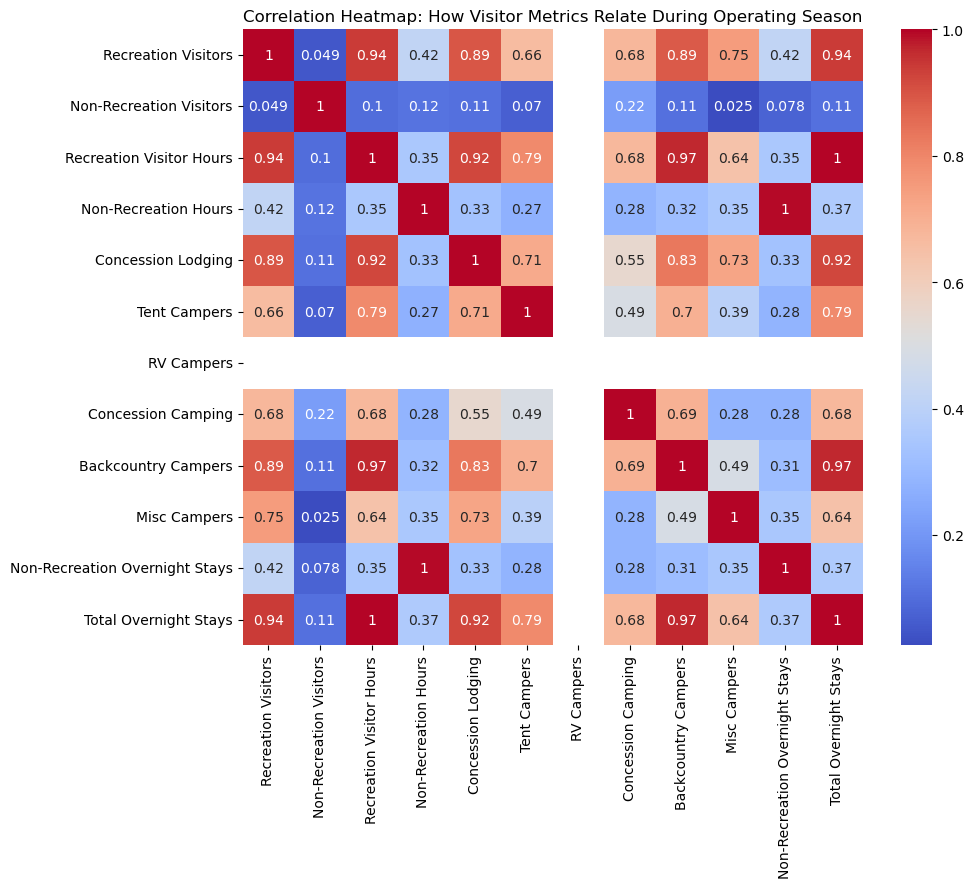

In [13]:
# Correlation heatmap to see relationships between different visitor types on operating months
plt.figure(figsize = (10, 8))

# Drop non-numeric/time columns to isolate metric relationships
corr_matrix = df_open.drop(columns = ['Year', 'Month', 'Month_Num', 'Date']).corr()
sns.heatmap(corr_matrix, annot = True, cmap = 'coolwarm')

plt.title('Correlation Heatmap: How Visitor Metrics Relate During Operating Season')
plt.show()

**Comparison to Full Dataset**:
- **Primary Drivers**: We still see that the 3 main drivers of visitation are `Recreation Visitors`, `Recreation Visitor Hours`, and `Total Overnight Stays`, but the correlations did drop slightly from 0.96 to 0.94.
- **Wilderness vs. Infrastructure:** `Backcountry Campers` and `Tent Campers` still have pretty high correlations with total recreation visitors, confirming that the park's growth is tied to trail and campsite usage.
- **Independent Metrics:** `Non-Recreation Visitors` correlations remain very low with almost all other categories.
- **Refined Accuracy**: The consistent, slight decrease in correlations suggests that the full dataset was somewhat overstating the impact of these variables, but the subset reveals the **true operational coupling** during the active season.

#### Seasonality & Monthly Outliers

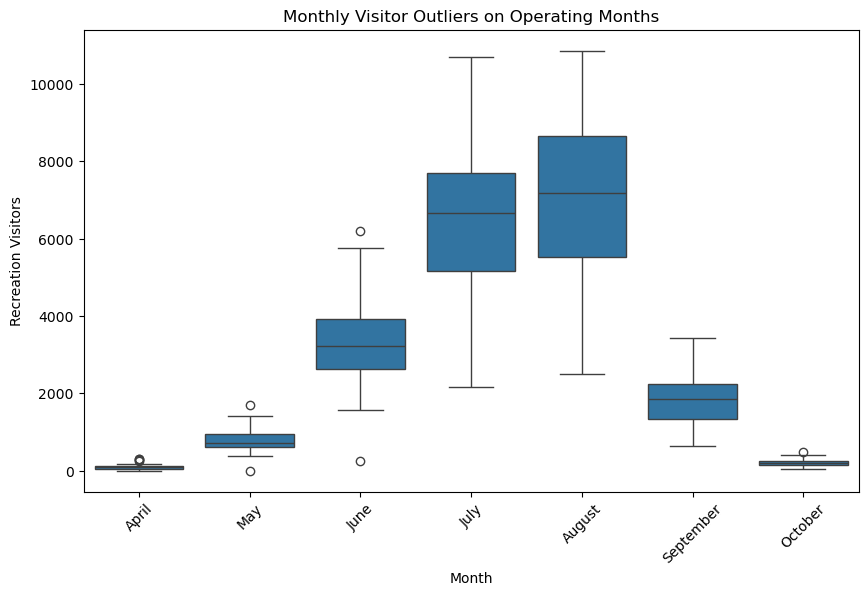

In [14]:
# Boxplot of monthly visitor outliers on subset
plt.figure(figsize = (10, 6))

sns.boxplot(x = 'Month', y = 'Recreation Visitors', data = df_open)

plt.title('Monthly Visitor Outliers on Operating Months')
plt.xticks(rotation = 45)
plt.show()

**Analysis of Monthly Trends**:
- **The Peak**: August has the highest median visitor count, which indicates it is the peak month for visitors.
- **Volatility**: Augest also displays the widest Interquartile Range (IQR), which means that it contains the most variation in visitation from year-to-year.
- **Stability in Shoulders**: The tight distributions of April, May, and October have the lowest medians, which indicate that early- and late-season visitation hasn't changed much over the past 46 years.
- **Anomalies**: May, June, and October contain some outliers, which means those months had either high or low visitation compared to their normal ranges.

# Analyzing Yearly/Monthly Visitation Stats

### Annual Visitation Analysis
In this section, we compare the statistis for the full calendar year against the "Open Season" (April-October). This helps quantify the impact of the park's extreme seasonality.

In [15]:
# Calculate annual statistics for the full year
annual_full = df.groupby('Year')['Recreation Visitors'].agg([
    'min',
    'mean',
    'max',
    'sum'
]).reset_index()
annual_full.columns = [
    'Year',
    'Full_Min',
    'Full_Avg',
    'Full_Max',
    'Total_Annual'
]

print('Annual Stats for Full Year:')
print(annual_full.head(10))

# Calculate annual statistics for the open season 
annual_open = df_open.groupby('Year')['Recreation Visitors'].agg([
    'min',
    'mean',
    'max',
    'sum'
]).reset_index()
annual_open.columns = [
    'Year',
    'Open_Min',
    'Open_Avg',
    'Open_Max',
    'Open_Total_Annual'
]

print('Annual Stats for Operating Season:')
print(annual_open.head(10))

# Merge tables for side-by-side comparison
annual_comparison = pd.merge(annual_full, annual_open, on = 'Year')

print('Annual Comparison:')
print(annual_comparison[[
    'Year',
    'Full_Min',
    'Open_Min',
    'Full_Avg',
    'Open_Avg',
    'Full_Max',
    'Total_Annual'
]].head(10))

Annual Stats for Full Year:
   Year  Full_Min     Full_Avg  Full_Max  Total_Annual
0  1979         0  1231.833333      5713         14782
1  1980         0  1248.083333      5934         14977
2  1981         0  1213.166667      5265         14558
3  1982         0  1103.166667      5012         13238
4  1983         0  1077.333333      4953         12928
5  1984         0   984.500000      4748         11814
6  1985         0  1397.916667      6050         16775
7  1986        22  2176.833333      9583         26122
8  1987        25  2646.666667     10861         31760
9  1988        12  2216.083333      9471         26593
Annual Stats for Operating Season:
   Year  Open_Min     Open_Avg  Open_Max  Open_Total_Annual
0  1979         0  2111.714286      5713              14782
1  1980         0  2139.571429      5934              14977
2  1981         0  2079.714286      5265              14558
3  1982         0  1891.142857      5012              13238
4  1983         0  1846.857143  

#### Annual Trends and the COVID-19 Impact

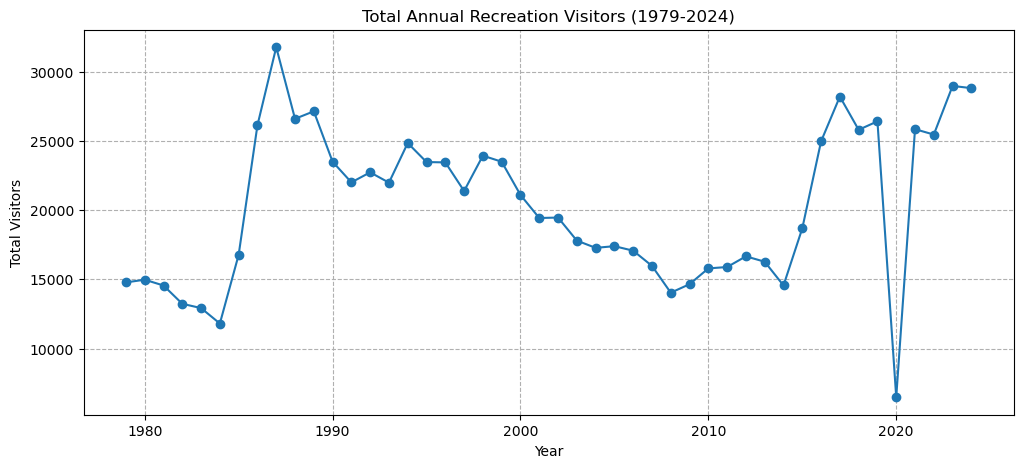

In [16]:
# Visualization of total anuual visitation trends
plt.figure(figsize = (12, 5))

plt.plot(annual_comparison['Year'], annual_comparison['Total_Annual'], marker = 'o')

plt.title('Total Annual Recreation Visitors (1979-2024)')
plt.xlabel('Year')
plt.ylabel('Total Visitors')
plt.grid(True, linestyle = '--')
plt.show()

**Observation**: The graph indicates that Isle Royale was most popular in 1987, which was followed by a gradual decline until 2014. Recently, visitation has surged back toward almost 30,000 visitors per year. A sharp decline is visible in 2020, which represents the impact of the COVID-19 pandemic.

#### The Seasonality Gap

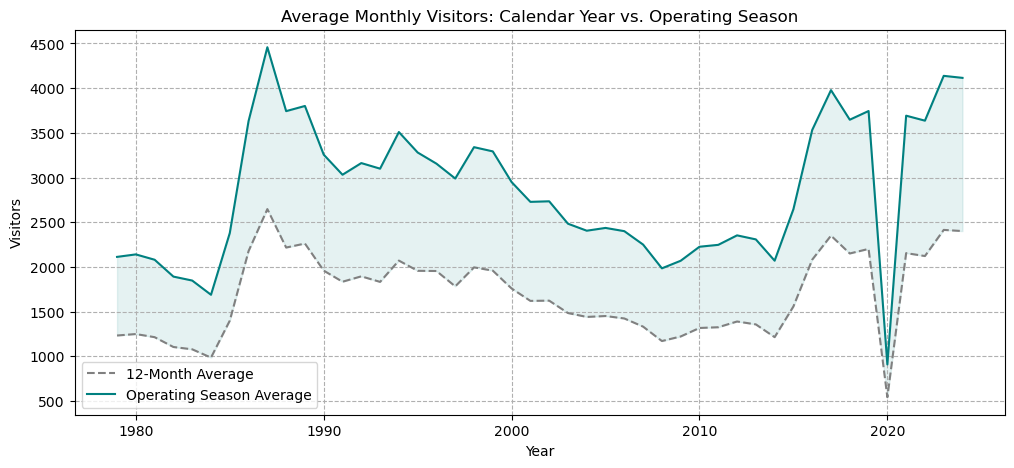

In [17]:
# Visualizing the difference between the calendar average and the operational average
plt.figure(figsize = (12, 5))

plt.plot(annual_comparison['Year'], annual_comparison['Full_Avg'], label = '12-Month Average', color = 'gray', linestyle = '--')
plt.plot(annual_comparison['Year'], annual_comparison['Open_Avg'], label = 'Operating Season Average', color = 'teal')
# Fill the area between to emphasize the "Hidden Pressure"
plt.fill_between(annual_comparison['Year'], annual_comparison['Full_Avg'], annual_comparison['Open_Avg'], color = 'teal', alpha = 0.1)

plt.title('Average Monthly Visitors: Calendar Year vs. Operating Season')
plt.xlabel('Year')
plt.ylabel('Visitors')
plt.legend()
plt.grid(True, linestyle = '--')
plt.show()

**Observation**: The teal line represents the average number of visitors per month only when the park is open (mid-April - October). The saded "seasonality gap" illustrates that by looking only at the 12-month average (gray dashed line), we underestimate the park's actual operational needs during the active season by nearly 50%.

### Monthly Visitation Analysis (Historical Extremes)
We now look at the historical performance of each month across the entire 46-year dataset to identify which months carry the highest operational burden.

In [18]:
# Define the categorical order for months
month_order = [
    'January',
    'February',
    'March',
    'April',
    'May',
    'June',
    'July',
    'August',
    'September',
    'October',
    'November',
    'December'
]

# Aggregate monthly stats and reindex to chronological order
monthly_stats = df.groupby('Month')['Recreation Visitors'].agg([
    'min',
    'max',
    'mean'
]).reindex(month_order)

print('Historical Monthly Extremes:')
print(monthly_stats)

Historical Monthly Extremes:
            min    max         mean
Month                              
January       0     78    29.369565
February      0    116    38.217391
March         0    419    79.000000
April         0    300    93.369565
May           0   1689   792.282609
June        240   6184  3358.956522
July       2160  10702  6527.326087
August     2494  10861  7157.500000
September   640   3421  1892.956522
October      32    474   196.347826
November      0    154    31.086957
December      0   1058   117.717391


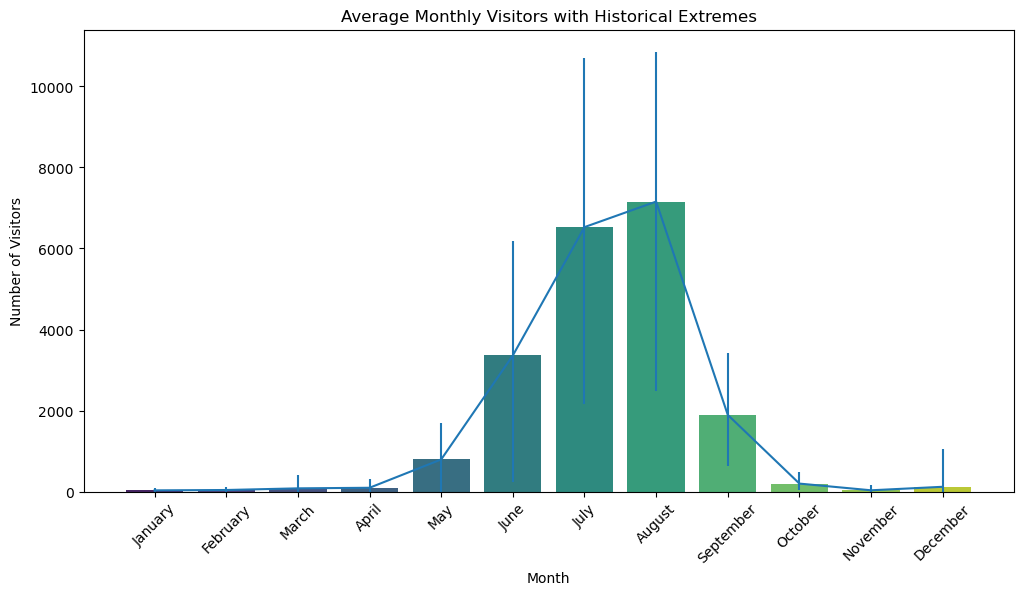

In [19]:
# Visualizing Monthly Averages with Range
plt.figure(figsize = (12, 6))

# Create bars for the mean
sns.barplot(x = monthly_stats.index, y = monthly_stats['mean'], hue = monthly_stats.index, palette = 'viridis')
# Add visual markers for the historical max and min to show the range
plt.errorbar(x = range(12), y = monthly_stats['mean'], 
             yerr = [monthly_stats['mean'] - monthly_stats['min'], monthly_stats['max'] - monthly_stats['mean']],
            label = 'Min/Max Range')

plt.title('Average Monthly Visitors with Historical Extremes')
plt.ylabel('Number of Visitors')
plt.xticks(rotation = 45)
plt.show()

**Observation - Analyzing Monthly Volatility and Extreme Events**:
This visualization illustrates the extreme seasonality of Isle Royale and provides a deeper look into the historical consistency of each month from 1979 to 2024.
- **Seasonal Peak**: The bars of **July and August** are not only the highest, which represents the peak of the operational season, but they also feature the longest error bars. This indicates that while these months are the most popular, they are also the most volatile.
- **Infrastructure Reliability**: The **June and September** averages show lower minimum values compared to their peaks, which suggests that these transitional months are more susceptible to external factors, like late snow and lake ice in the spring or early severe storms in the fall. These factors can drastically reduce visitation compared to the stable mid-summer window.
- **Zero-Baseline Consistency**: The months of **January, February, November, and December** show almost no height and minimal error bars. This visually confirms the total seasonal closure of the park, where the only recorded visitors are likely administrative or research personnel, creating a near-zero baseline for the majority of the year.
- **Operational Strain**: The "Historical Max" marker for **August** (reaching over 10,000 visitors) highlights the maximum capacity measue the park has ever faced. For management, the gap between the bar (average) and the top of the line (max) represents the "surge capacity" the park must be prepared to handle.

#### Annual Peak Performance
To understand consistency in seasonality, we identify which month serves as the "Peak" for every year in the dataset.

In [20]:
# Monthly visitation analysis per year
yearly_monthly_stats = df.groupby([
    'Year', 
    'Month'
])['Recreation Visitors'].sum().reset_index()

# Find the peak month for every year
peaks_by_year = df.loc[df.groupby('Year')['Recreation Visitors'].idxmax()]

print('Monthly Visitation Peaks per Year:')
print(peaks_by_year[[
    'Year',
    'Month',
    'Recreation Visitors'
]].head(10))

Monthly Visitation Peaks per Year:
     Year   Month  Recreation Visitors
7    1979  August                 5713
19   1980  August                 5934
31   1981  August                 5265
43   1982  August                 5012
55   1983  August                 4953
67   1984  August                 4748
79   1985  August                 6050
91   1986  August                 9583
103  1987  August                10861
115  1988  August                 9471


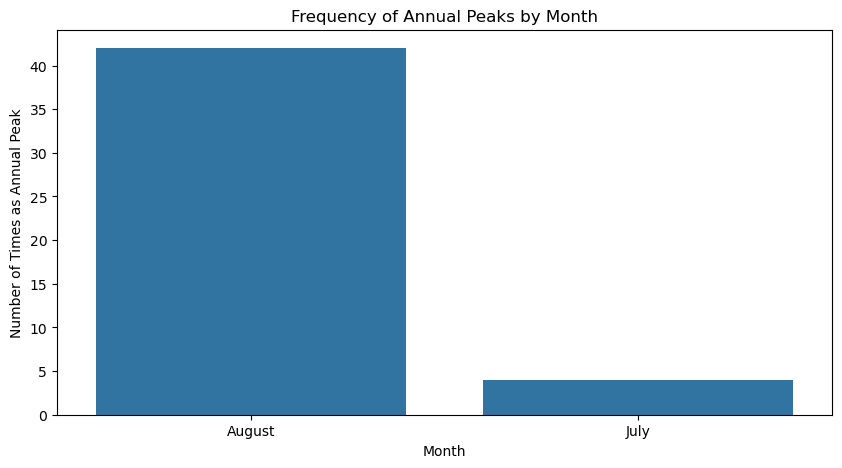

In [21]:
# Visualizing Peak Month Frequency
plt.figure(figsize = (10, 5))

# Count how many times each month has been the annual peak
peak_counts = peaks_by_year['Month'].value_counts().reindex(month_order).fillna(0)

# Filter and sort the months that actually have peaks
peak_counts_sorted = peak_counts[peak_counts > 0].sort_values(ascending = False)

# Create a bar plot to visualize the frequency
sns.barplot(x = peak_counts_sorted.index, y = peak_counts_sorted.values)

plt.title('Frequency of Annual Peaks by Month')
plt.xlabel('Month')
plt.ylabel('Number of Times as Annual Peak')
plt.show()

**Observation - Identifying the Definitive Seasonal Peak**:
This bar chart visualizes the frequency with which each month served as the annual peak for recreation visitation across the 46-year study period.
- **August Domination**: The data reveals that **August** is the undisputed peak for Isle Royale, serving as the highest visitation month for nearly every year in the dataset. This suggests that regardless of economic shifts or minor climate variations, the core demand for the park remains locked into a very specific late-summer window.
- **Predictability for Resource Allocation**: From a management perspective, this high frequency allows for precise planning. Since the peak does not shift significantly from year to year, the National Park Service can concentrate its seasonal staffing, maintenance projects, and ferry schedules with high confidence in where the maximum impact will occur.
- **The "July" Exception**: The small bar for **July** indicates that while it is a high-volume month, it very rarely surpasses August. These few instances may correspond to historical anamolies, such as extreme weather events in late August or specific administrative changes in ferry operations.
- **Comparison to Other Months**: The total absence of other months as peaks reinforces the extreme seasonality discussed earlier. There is no "secondary peak" in the spring or fall, which confirms that the park operates on a single-surge model rather than a multi-modal visitation cycle.


# Analyzing Big Events Between 1979-2024

In 1980, Isle Royale was recognized as a UNESCO Biosphere Reserve. Was this milestone a driver for the pattern of recreation vs non-recreation visitors in that decade and the following decades?

In [22]:
# Make a subset dataframe that contains only rec. vs non-rec. visitors data
df_rec = df[['Year', 'Recreation Visitors', 'Non-Recreation Visitors', 'Non-Recreation Overnight Stays', 'Total Overnight Stays']].copy()
df_rec.rename(columns = {
    'Year': 'Year',
    'Recreation Visitors': 'Rec',
    'Non-Recreation Visitors': 'Non-rec',
    'Non-Recreation Overnight Stays': 'Non-rec Stays',
    'Total Overnight Stays': 'Total Stays'
}, inplace = True)

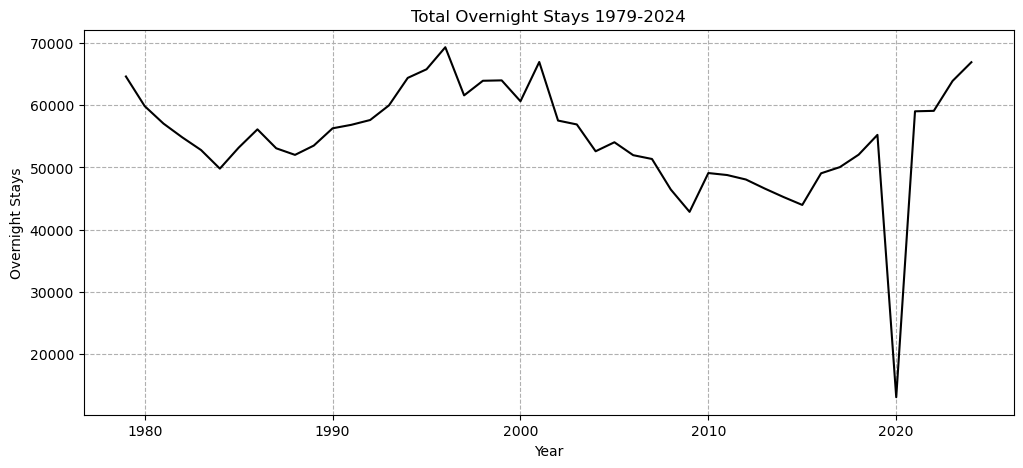

In [23]:
# Overview of total stay
plt.figure(figsize = (12, 5))

total_stays = df_rec[['Year', 'Total Stays']].groupby('Year').sum().reset_index()

plt.plot(total_stays['Year'], total_stays['Total Stays'], label = 'Total Overnight Stays', color = 'black')

plt.title('Total Overnight Stays 1979-2024')
plt.xlabel('Year')
plt.ylabel('Overnight Stays')
plt.grid(True, linestyle = '--')
plt.show()

Although recreation visitors took the majority of the total visitors to Isle Royale and peaked in 1987, the total overnight stays peaked in 1996. The total overnight stays include both non-recreation and recreation stays. Therefore, it could be used to assess the potential impact of the UNESCO recognition in 1980 on visiting patterns.

According to the plot above, the total overnight stays decreased by 10,000 stays in the first few years after the big event. It generally increased in the next decade and dropped back to the same level as it was in 1980.

## 1980 - 1989

In [24]:
sub80s = df_rec[(df_rec['Year'] >= 1980) & (df_rec['Year'] <= 1989)].groupby('Year').sum().reset_index()
# sub80s

In [25]:
sub80snorm = sub80s / sub80s.max()
# sub80snorm

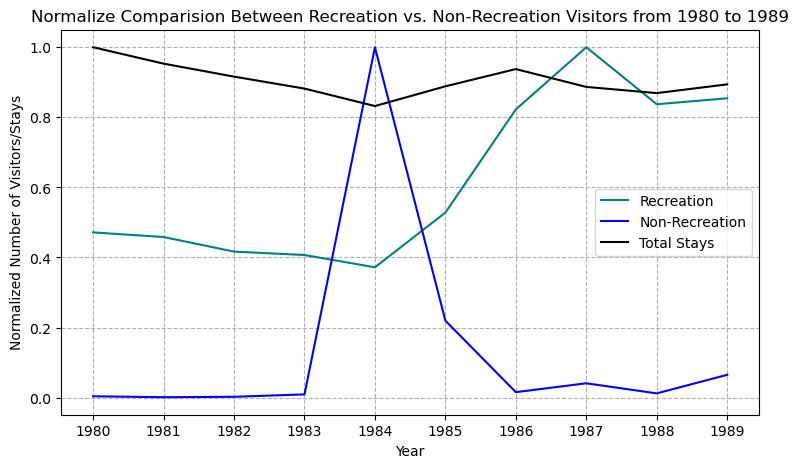

In [26]:
# Plot the total visitors for recreation vs. non-recreation visiting in the 1980s
plt.figure(figsize = (9, 5))

plt.plot(sub80s['Year'], sub80snorm['Rec'], label = 'Recreation', color = 'teal')
plt.plot(sub80s['Year'], sub80snorm['Non-rec'], label = 'Non-Recreation', color = 'blue')
plt.plot(sub80s['Year'], sub80snorm['Total Stays'], label = 'Total Stays', color = 'black')

plt.title('Normalize Comparision Between Recreation vs. Non-Recreation Visitors from 1980 to 1989')
plt.xlabel('Year')
plt.ylabel('Normalized Number of Visitors/Stays')
plt.xticks(sub80s['Year'])
plt.legend()
plt.grid(True, linestyle = '--')
plt.show()

Because the values of `Recreation Visitors` outnumber that of `Non-Recreation Visitors`, direct comparison wasn't effective. The number of visitors was normalized by dividing the total number of visitors per year by the maximum number of visitors in this period (1980-1989).

The plots above shows that non-recreation visitors peaked in 1984 while recreation visitors did in 1987. During this period, the total overnight stays did not change much. This means there was a potential impact from the event on the number of non-recreation visitors.

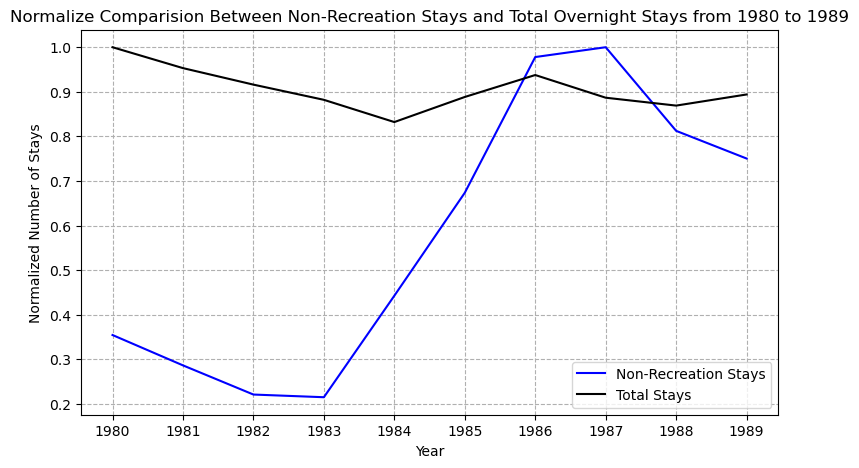

In [27]:
# Compare non-rec stays and total stays
plt.figure(figsize = (9, 5))

plt.plot(sub80s['Year'], sub80snorm['Non-rec Stays'], label = 'Non-Recreation Stays', color = 'blue')
plt.plot(sub80s['Year'], sub80snorm['Total Stays'], label = 'Total Stays', color = 'black')

plt.title('Normalize Comparision Between Non-Recreation Stays and Total Overnight Stays from 1980 to 1989')
plt.xlabel('Year')
plt.ylabel('Normalized Number of Stays')
plt.xticks(sub80s['Year'])
plt.legend()
plt.grid(True, linestyle = '--')
plt.show()

While the peak non-recreation visitors was in 1984, the peak non-recreation overnight stays was seen in 1987. Compared to the previous plot, although non-recreation visitors decreased from 1984 to 1987, the duration of their stays extended dramatically. This could reflect the indirect impact of the UNESCO status on adminisitrative, research, or non-tourist activities on the island.

## 1980 - 1989

Since there was a steep increase in recreation visitors during the 1980s, focusing on this period only to assess the impact of the UNESCO title on visiting pattern might be biased. We extended the examined period to 1999.

In [28]:
sub80_90s = df_rec[(df_rec['Year'] >= 1980) & (df_rec['Year'] <= 1999)].groupby('Year').sum().reset_index()
# sub80_90s
sub80_90s_norm = sub80_90s / sub80_90s.max()

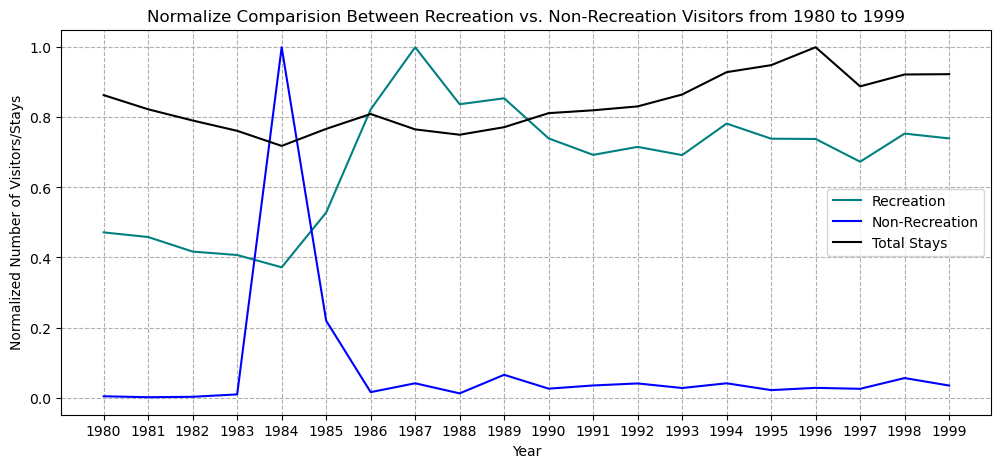

In [29]:
# Compare rec vs. non-rec visitors
plt.figure(figsize = (12, 5))

plt.plot(sub80_90s['Year'], sub80_90s_norm['Rec'], label = 'Recreation', color = 'teal')
plt.plot(sub80_90s['Year'], sub80_90s_norm['Non-rec'], label = 'Non-Recreation', color = 'blue')
plt.plot(sub80_90s['Year'], sub80_90s_norm['Total Stays'], label = 'Total Stays', color = 'black')

plt.title('Normalize Comparision Between Recreation vs. Non-Recreation Visitors from 1980 to 1999')
plt.xlabel('Year')
plt.ylabel('Normalized Number of Visitors/Stays')
plt.xticks(sub80_90s['Year'])
plt.legend()
plt.grid(True, linestyle = '--')
plt.show()

When examining the longer period, the peaks of either type of visitors remained the same as in the previous analysis. The patterns for both type of visitors after their peaks remained relatively stable, but overall, there was an increase in the number of visitors in 1999 compared to that in 1980. The title might make Isle Royale known to more people based on these trends.

# Analyzing Trends in Services & Stays

### Comparing Types of Stays Annually

In [30]:
# RV not included as there are no RV campers in the dataset

# Setting up different overnight stay variables for comparison during recreation season
# Sorted by Annual Total to display stay types and year by largest total visitation

con_lodge = df_open.groupby('Year')['Concession Lodging'].agg(['min', 'mean', 'max', 'sum']).reset_index()
con_lodge.columns = ['Year', 'Min', 'Mean', 'Max', 'Annual Total']

sort_con_lodge = con_lodge.sort_values(by = 'Annual Total', ascending = False)

con_camp = df_open.groupby('Year')['Concession Camping'].agg(['min', 'mean', 'max', 'sum']).reset_index()
con_camp.columns = ['Year', 'Min', 'Mean', 'Max', 'Annual Total']
sort_con_camp = con_camp.sort_values(by = 'Annual Total', ascending = False)

tent_camp = df_open.groupby('Year')['Tent Campers'].agg(['min', 'mean', 'max', 'sum']).reset_index()
tent_camp.columns = ['Year', 'Min', 'Mean', 'Max', 'Annual Total']
sort_tent_camp = tent_camp.sort_values(by = 'Annual Total', ascending = False)

back_camp = df_open.groupby('Year')['Backcountry Campers'].agg(['min', 'mean', 'max', 'sum']).reset_index()
back_camp.columns = ['Year', 'Min', 'Mean', 'Max', 'Annual Total']
sort_back_camp = back_camp.sort_values(by = 'Annual Total', ascending = False)

misc_camp = df_open.groupby('Year')['Misc Campers'].agg(['min', 'mean', 'max', 'sum']).reset_index()
misc_camp.columns = ['Year', 'Min', 'Mean', 'Max', 'Annual Total']
sort_misc_camp = misc_camp.sort_values(by = 'Annual Total', ascending = False)

# Print tables comparing the top five years for each camping type by annual total.
print('Top 5 Concession Lodge Stay Years by Annual Total:')
print(sort_con_lodge.head(5))
print('Top 5 Concession Camp Stay Years by Annual Total:')
print(sort_con_camp.head(5))
print('Top 5 Tent Camping Stay Years by Annual Total:')
print(sort_tent_camp.head(5))
print('Top 5 Backcountry Camping Stay Years by Annual Total:')
print(sort_back_camp.head(5))
print('Top 5 Misc. Camping Stay Years Annual Total:')
print(sort_misc_camp.head(5))

Top 5 Concession Lodge Stay Years by Annual Total:
    Year  Min         Mean   Max  Annual Total
44  2023    0  1957.000000  4895         13699
40  2019    0  1758.285714  4364         12308
45  2024    0  1638.285714  4376         11468
38  2017    0  1624.571429  4326         11372
43  2022    0  1588.428571  4175         11119
Top 5 Concession Camp Stay Years by Annual Total:
    Year  Min        Mean   Max  Annual Total
9   1988    0  338.285714  1291          2368
12  1991    0  264.571429   918          1852
7   1986    0  249.285714   846          1745
5   1984    0  243.428571  1049          1704
15  1994    0  232.571429   708          1628
Top 5 Tent Camping Stay Years by Annual Total:
    Year  Min         Mean    Max  Annual Total
0   1979    0  3877.142857  12695         27140
1   1980    0  2820.000000   8428         19740
15  1994    0  1237.857143   3219          8665
17  1996    0  1191.857143   3307          8343
16  1995    0  1168.285714   2983          8178
Top 5 

In [31]:
# Add visualization for top 5 years in each category

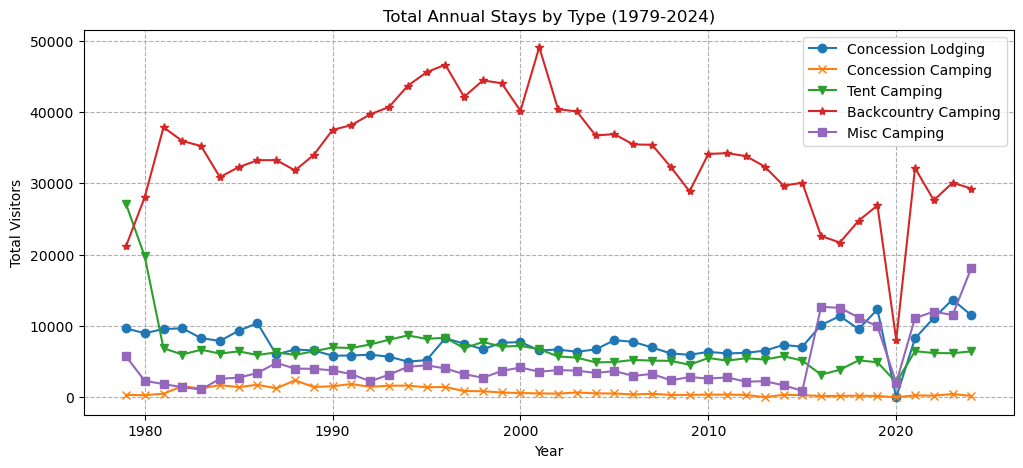

In [32]:
plt.figure(figsize = (12, 5))

plt.plot(con_lodge['Year'], con_lodge['Annual Total'], marker = 'o')
plt.plot(con_camp['Year'], con_camp['Annual Total'], marker = 'x')
plt.plot(tent_camp['Year'], tent_camp['Annual Total'], marker = 'v')
plt.plot(back_camp['Year'], back_camp['Annual Total'], marker = '*')
plt.plot(misc_camp['Year'], misc_camp['Annual Total'], marker = 's')

plt.title('Total Annual Stays by Type (1979-2024)')
plt.xlabel('Year')
plt.ylabel('Total Visitors')
plt.grid(True, linestyle = '--')
plt.legend(["Concession Lodging", "Concession Camping", "Tent Camping", "Backcountry Camping", "Misc Camping"], loc = "upper right")
plt.show()

The above graph illustrates total annual stays by each stay type. Backcountry camping was by far the most popular type of stay consistently from 1979 through 2024. Interestingly, tent camping was initially the most prevalent type of camping, but sharply fell and became comparable to all other camping types with the exception of backcountry camping. Concession lodging and miscellaneous camping saw a decline in prevalence but then increased beginning around 2015 and has slowly continued to grow (with the exception of 2020). Concession camping has remained constistently low from 1979 through 2024. 

### Annual Concession vs. Non-Concession Stays

In [33]:
# Merge relevant tables for comparison

# Set new column names for easier comparison when in tables
con_lodge.columns = ['Year', 'Con_Lodge Min', 'Con_Lodge Avg', 'Con_Lodge Max', 'Con_Lodge Total']
con_camp.columns = ['Year', 'Con_Camping Min', 'Con_Camping Avg', 'Con_Camping Max', 'Con_Camping Total']
tent_camp.columns = ['Year', 'Tent_Camping Min', 'Tent_Camping Avg', 'Tent_Camping Max', 'Tent_Camping Total']
back_camp.columns = ['Year', 'Back_Country_Camping Min', 'Back_Country_Camping Avg', 'Back_Country_Camping Max', 'Back_Country_Camping Total']
misc_camp.columns = ['Year', 'Misc_Camping Min', 'Misc_Camping Avg', 'Misc_Camping Max', 'Misc_Camping Total']

# Merge concession tables
con_stays = pd.merge(con_lodge, con_camp, on = 'Year').sort_values(by = 'Year').reset_index(inplace = False)
con_stays = con_stays.drop('index', axis = 1)

# Merge non-concession, non-misc camping now to be used later
non_misc_camp_stays = pd.merge(tent_camp, back_camp, on = 'Year').sort_values(by = 'Year').reset_index(inplace = False)
non_misc_camp_stays = non_misc_camp_stays.drop('index', axis = 1)                 

# Merge all non-concession camping
non_con_camp_stays = pd.merge(non_misc_camp_stays, misc_camp, on = 'Year').sort_values(by = 'Year')

# Print tables on concession and non-concession stays by annual total. Use tail to show most recent years
print('Concession Stays by Annual Total:')
print(con_stays.tail(5))
print('Non-concession Stays by Annual Total:')
print(non_con_camp_stays.tail(5))

Concession Stays by Annual Total:
    Year  Con_Lodge Min  Con_Lodge Avg  Con_Lodge Max  Con_Lodge Total  \
41  2020              0       0.000000              0                0   
42  2021              0    1178.428571           2757             8249   
43  2022              0    1588.428571           4175            11119   
44  2023              0    1957.000000           4895            13699   
45  2024              0    1638.285714           4376            11468   

    Con_Camping Min  Con_Camping Avg  Con_Camping Max  Con_Camping Total  
41                0         0.000000                0                  0  
42                0        36.857143              144                258  
43                0        31.000000               96                217  
44                0        63.571429              196                445  
45                0        27.571429               88                193  
Non-concession Stays by Annual Total:
    Year  Tent_Camping Min  Tent_

In [34]:
#Add visualization(s) comparing con_stays and non_con_camp_stays

### Indoor Lodging vs. Outdoor Camping Stays

In [35]:
# Merge all camping tables for comparison to lodging
# Miscellaneous is excluded as it includes some options for indoor camping

all_outdoor_camp = pd.merge(con_camp, non_misc_camp_stays, on = 'Year').sort_values(by = 'Year').reset_index(inplace = False)
all_outdoor_camp = all_outdoor_camp.drop('index', axis = 1)

# Print tables on indoor and outdoor stays by annual total. Use tail to show most recent years
print('Indoor Stays by Annual Total:')
print(con_lodge.tail(5))
print('Outdoor Stays by Annual Total:')
print(all_outdoor_camp.tail(5))

Indoor Stays by Annual Total:
    Year  Con_Lodge Min  Con_Lodge Avg  Con_Lodge Max  Con_Lodge Total
41  2020              0       0.000000              0                0
42  2021              0    1178.428571           2757             8249
43  2022              0    1588.428571           4175            11119
44  2023              0    1957.000000           4895            13699
45  2024              0    1638.285714           4376            11468
Outdoor Stays by Annual Total:
    Year  Con_Camping Min  Con_Camping Avg  Con_Camping Max  \
41  2020                0         0.000000                0   
42  2021                0        36.857143              144   
43  2022                0        31.000000               96   
44  2023                0        63.571429              196   
45  2024                0        27.571429               88   

    Con_Camping Total  Tent_Camping Min  Tent_Camping Avg  Tent_Camping Max  \
41                  0                 0        298.0000

In [36]:
# Add visualization(s) comparing indoor and outdoor stays